### 문서 군집화
- KMeans : k값 지정 -> k값이 과연 맞는지, k 고르는 방법
- 다른 군집 방법

- 라벨 없는 문서가 상당히 많다
- 고객 문의, 리뷰, 제보, 메모 등

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "dragonkue/BGE-m3-ko",
    device="cpu"
)

data = pd.read_csv("../data/11-1_뉴스정제.csv")
data.head(3)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...


In [2]:
doc_vecs = model.encode(data['정제본문'].tolist(), 
                        normalize_embeddings=True, 
                        show_progress_bar=True,
                        batch_size=4)

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

In [3]:
doc_vecs.shape

(1000, 1024)

In [4]:
data['카테고리'].unique()

<StringArray>
['경제', 'IT과학']
Length: 2, dtype: str

In [5]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(doc_vecs)
data['군집'] = km.labels_
data['군집'].value_counts()

군집
0    647
1    353
Name: count, dtype: int64

In [6]:
# 군집과 카테고리가 얼마나 맞는지 확인

pd.crosstab(data['군집'], data['카테고리'])

카테고리,IT과학,경제
군집,,
0,403,244
1,97,256


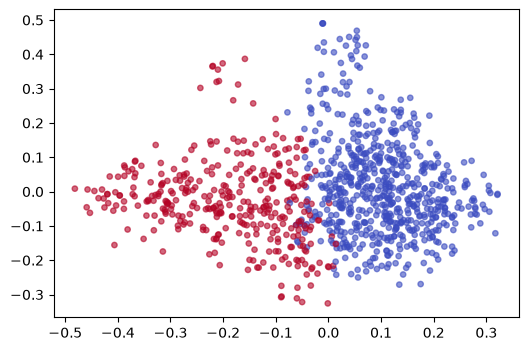

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=2).fit_transform(doc_vecs)    # 벡터를 2차원으로 줄임

plt.figure(figsize=(6,4))
plt.scatter(coords[:,0], coords[:,1], c=data['군집'], cmap="coolwarm", s=15, alpha=0.6)
plt.show()

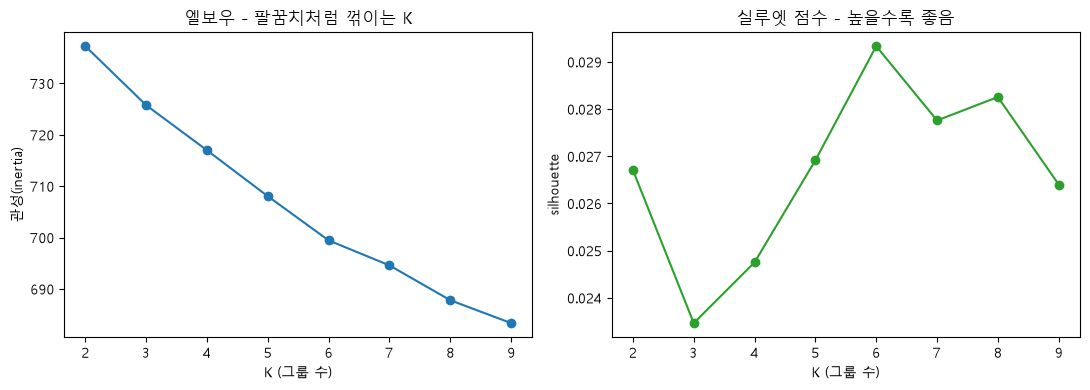

In [15]:
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

from sklearn.metrics import silhouette_score

k_candidates = range(2, 10)
inertias = []
silhouettes = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(doc_vecs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(doc_vecs, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(k_candidates), inertias, marker="o")
ax[0].set_title("엘보우 - 팔꿈치처럼 꺾이는 K")
ax[0].set_xlabel("K (그룹 수)"); ax[0].set_ylabel("관성(inertia)")
ax[1].plot(list(k_candidates), silhouettes, marker="o", color="tab:green")
ax[1].set_title("실루엣 점수 - 높을수록 좋음")
ax[1].set_xlabel("K (그룹 수)"); ax[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

#### 실루엣 점수 분석 결과, k=6이 최적!

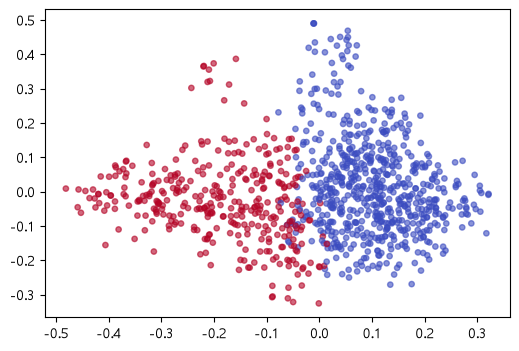

In [16]:
coords = PCA(n_components=6).fit_transform(doc_vecs)    # 벡터를 2차원으로 줄임

plt.figure(figsize=(6,4))
plt.scatter(coords[:,0], coords[:,1], c=data['군집'], cmap="coolwarm", s=15, alpha=0.6)
plt.show()

### DBSCAN
- 가까운 이웃이 충분히 많은 점들만 그룹으로 묶고
- 멀리 있는 경우 -> 이상치 처리
- 그룹 수를 정해주지 않아도 되지만, 얼마나 가까우면 이웃인가(eps) 정해줘야 함
- 문서는 코사인 비교 -> metric = "cosine"

In [17]:
from sklearn.cluster import DBSCAN

dbscan_labels = DBSCAN(eps=0.45, min_samples=3, metric="cosine").fit_predict(doc_vecs)
n_groups = len(set(dbscan_labels) - {-1})
n_outliers = int((dbscan_labels == -1).sum())
print("DBSCAN이 찾은 그룹 수:", n_groups)
print("이상치(-1)로 빠진 문서 수:", n_outliers)
# 예상 출력: 그룹 몇 개 + 이상치 수십 개 (뉴스는 넓게 퍼져 이상치가 꽤 나옵니다)

DBSCAN이 찾은 그룹 수: 43
이상치(-1)로 빠진 문서 수: 624
